In [28]:
import pandas as pd

In [29]:
df = pd.read_csv('heart.csv')

In [30]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [31]:
from sklearn.model_selection import train_test_split

X , Y = df.drop('target', axis=1), df['target']

X_train, X_test , Y_train, Y_test = train_test_split(X,Y,test_size=0.4 , random_state =9)

In [32]:
## Scale-Insensitive

In [33]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier()
forest.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
from sklearn.naive_bayes import GaussianNB

nb_clf = GaussianNB()
nb_clf.fit(X_train,Y_train)

,priors,None
,var_smoothing,1e-09


In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train,Y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Scale_Sensitive 

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression()
log.fit(X_train_scaled, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train_scaled, Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
forest.score(X_test, Y_test)

0.9853658536585366

In [41]:
nb_clf.score(X_test, Y_test)

0.8463414634146341

In [42]:
gb_clf.score(X_test, Y_test)

0.9707317073170731

In [43]:
knn.score(X_test_scaled, Y_test)

0.8536585365853658

In [44]:
log.score(X_test_scaled, Y_test)

0.8731707317073171

In [45]:
svc.score(X_test_scaled, Y_test)

0.9341463414634147

# Accuracy: 100 -> 80 -> 80% -> 0.88
# Precision: 200 -> 200 have disease -> 100 actually have -> 50%
# Recalls : 100 patients with heart disease -> 100%

In [46]:
from sklearn.metrics import recall_score

Y_preds = forest.predict(X_test)
print('Forest:', recall_score(Y_test, Y_preds))

Y_preds = nb_clf.predict(X_test)
print('NB:', recall_score(Y_test, Y_preds))


Y_preds = gb_clf.predict(X_test)
print('GB:', recall_score(Y_test, Y_preds))

Y_preds = knn.predict(X_test_scaled)
print('KNN:', recall_score(Y_test, Y_preds))


Y_preds = log.predict(X_test_scaled)
print('Log:', recall_score(Y_test, Y_preds))

Y_preds = svc.predict(X_test_scaled)
print('Svc:', recall_score(Y_test, Y_preds))


Forest: 0.9859154929577465
NB: 0.9014084507042254
GB: 0.9859154929577465
KNN: 0.8732394366197183
Log: 0.92018779342723
Svc: 0.9530516431924883


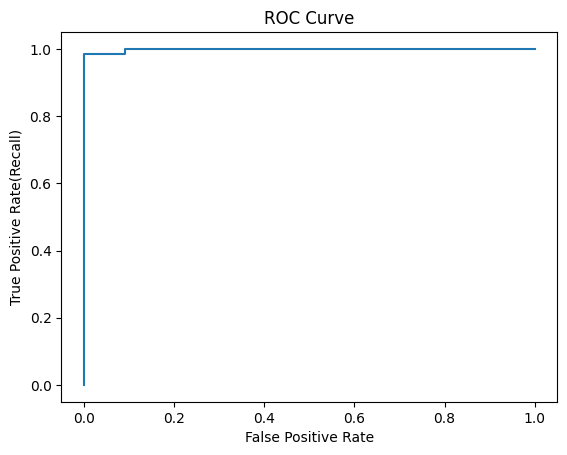

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

Y_probs = forest.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, Y_probs)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate(Recall)')
plt.title('ROC Curve')
plt.show()

In [48]:
roc_auc_score(Y_test, Y_probs)

0.9987130907271037

# Hyperparameter Tuning

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500, 600, 700],
    #'max_depth': [None, 10, 20, 30],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4],
    #'max_features': ['sqrt', 'log2', None]

}

forest = RandomForestClassifier(n_jobs=-1, random_state=9)

grid_search = GridSearchCV(forest, param_grid, cv=3, n_jobs=-1, verbose=2)
    

In [50]:
grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,estimator,RandomForestC...andom_state=9)
,param_grid,"{'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [51]:
best_forest = grid_search.best_estimator_

In [52]:
best_forest

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Feature importances

<function matplotlib.pyplot.show(close=None, block=None)>

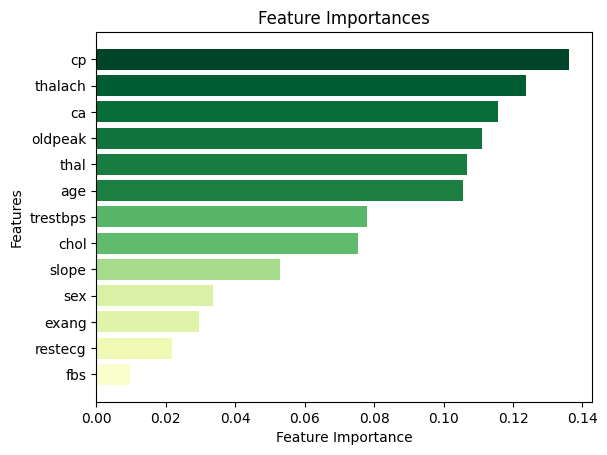

In [53]:
import numpy as np

feature_importances = best_forest.feature_importances_
features = best_forest.feature_names_in_

sorted_idx = np.argsort(feature_importances)
sorted_features = features[sorted_idx]
sorted_importances = feature_importances[sorted_idx]

colors = plt.cm.YlGn(sorted_importances / max(sorted_importances))

plt.barh(sorted_features, sorted_importances, color=colors)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importances')
plt.show

<Axes: >

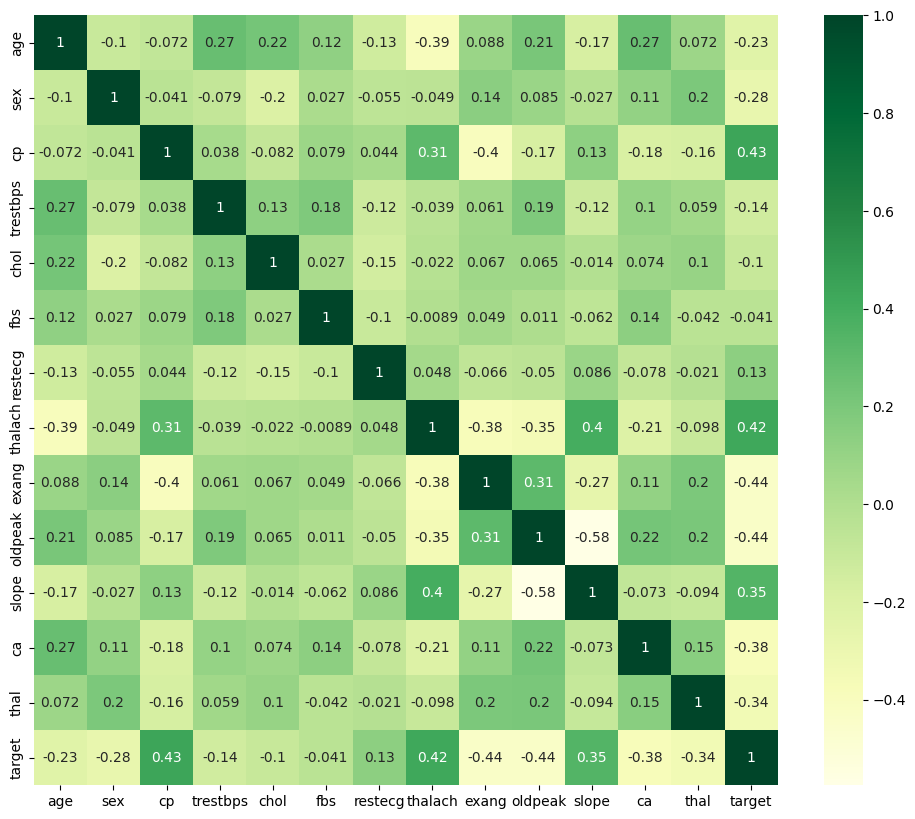

In [54]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='YlGn')